In [38]:
#!/usr/bin/env python3
"""
Offset-free MPC (CT) migrated from `control/offset_free_CT.ipynb`.

- Loads A, B, C, trained Koopman-related modules, scalers, and sim setup
- Builds transformed representation with T_real
- Runs target estimation + MPC closed-loop simulation
- Saves plots under repository `figures/`
- Prints the objective line exactly as in the notebook:
  "Closed-loop objective function value: <value>"

Requires `src/helper` and `src/models` to be importable.
"""

from __future__ import annotations

import sys
from pathlib import Path
from typing import Tuple

import joblib
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from tqdm import tqdm

# Optional deps used in helper/model stack
import torch  # noqa: F401
import cvxpy as cp  # noqa: F401

# neuromancer symbols are imported in notebook; here they are required indirectly via helper/models loading
from neuromancer.modules import blocks  # type: ignore
from neuromancer.system import Node, System  # type: ignore
from neuromancer.problem import Problem  # type: ignore
from neuromancer.loss import PenaltyLoss  # type: ignore

# Add Identification directory to path for baseline_inference import
identification_path = Path.cwd().resolve().parent / 'Identification'
if str(identification_path) not in sys.path:
    sys.path.append(str(identification_path))
import baseline_inference  # type: ignore




In [39]:
baseline_inference.init()

Model initialized successfully!
A matrix shape: (24, 24)
B matrix shape: (24, 3)
Scalers loaded for 3 outputs and 3 inputs


In [40]:
# --------------------------- Repository paths ---------------------------------

def get_repo_root() -> Path:
    # In a notebook, __file__ is not defined; use cwd as a fallback
    return Path.cwd().resolve().parent


def get_figures_dir(repo_root: Path) -> Path:
    figures = repo_root / "figures"
    figures.mkdir(parents=True, exist_ok=True)
    return figures


# # Ensure `src` is on PYTHONPATH
REPO_ROOT = get_repo_root()
SRC_PATH = REPO_ROOT / 'src'
if SRC_PATH.as_posix() not in sys.path:
    sys.path.append(SRC_PATH.as_posix())

import helper  # type: ignore
import models  # type: ignore


# # ------------------------------ IO utilities ----------------------------------






# def load_scalers(data_dir: Path):
#     scaler = joblib.load((data_dir / 'scaler.pkl').as_posix())
#     scalerU = joblib.load((data_dir / 'scalerU.pkl').as_posix())
#     return scaler, scaler



In [41]:
data_dir = REPO_ROOT / '../data'
figures_dir = get_figures_dir(REPO_ROOT)

# Load matrices for matrix_C=False as in notebook
matrix_C = True
A = np.load(f"../data/A_parsimK.npy")
B = np.load(f"../data/B_parsimK.npy")
C = np.load(f"../data/C_parsimK.npy")

# # Resample A and B from Ts=1 to Ts=10 seconds
# Ts_old = 1.0    # original timestep in seconds
# Ts_new = 10.0   # desired timestep in seconds

# # import scipy.linalg as la

# # # Convert to continuous through matrix log
# # Ac = la.logm(A) / Ts_old
# # Bc = np.linalg.solve(Ac, (A - np.eye(A.shape[0]))) @ B

# # # Re-discretize at Ts_new
# # A = A_10 = la.expm(Ac * Ts_new)
# # B = B_10 = np.linalg.solve(Ac, (A_10 - np.eye(A.shape[0]))) @ Bc

# # A = np.real(A)  # or use np.real(A_10) if you're sure
# # B = np.real(B)

# # np.save(f"../data/A_parsimK_Ts.npy", A)
# # np.save(f"../data/B_parsimK_Ts.npy", B)

# A_10 = np.linalg.matrix_power(A, int(Ts_new / Ts_old))

# sum_term = np.zeros_like(B)
# A_power = np.eye(A.shape[0])
# for i in range(int(Ts_new / Ts_old)):
#     sum_term += A_power @ B
#     A_power = A @ A_power
# B_10 = sum_term

# A = A_10
# B = B_10


nz, nu = B.shape
ny = C.shape[0]

# Disturbance model dimension
F = np.eye(ny)
nd = F.shape[1]

# Block diagonalization
T_real, A_block = helper.ident.real_block_diagonalize(A)

# Transform A to check
A_transformed = inv(T_real) @ A @ T_real
print("Close to block diagonal?", np.allclose(A_block, A_transformed, atol=1e-6))

# Backtransform A_block to verify it equals A
A_backtransformed = T_real @ A_block @ inv(T_real)
print("Backtransformation equals original A?", np.allclose(A, A_backtransformed, atol=1e-6))
# T_real = np.eye(nz)  # Use identity for now, as A is already block diagonal



Close to block diagonal? True
Backtransformation equals original A? True


In [42]:
B.shape

(8, 3)

In [43]:
# Apply transformation as in notebook (Cell 6)
A = inv(T_real) @ A @ T_real
B = inv(T_real) @ B
C = C @ T_real

# Load scalers - baseline (3 features: T1,T2,T4) and MPC (4 features: T1,T2,T4,L)
scaler_baseline = joblib.load("../data/scaler_baseline.pkl")  # 3-feature for baseline outputs
scalerU_baseline = joblib.load("../data/scalerU_baseline.pkl")  # for baseline inputs
scaler = joblib.load("../data/scaler.pkl")  # 4-feature scaler for MPC models
scalerU = joblib.load("../data/scalerU.pkl")  # for MPC inputs
# Sim setup
loaded_setup = joblib.load("sim_setup.pkl")


In [44]:

y_start = loaded_setup['y_start']
y_start_ns = loaded_setup.get('y_start_ns')
reference_ns = loaded_setup.get('reference_ns')
y_setpoint = loaded_setup['reference'][:, 0]
u_sp = loaded_setup['reference_u'][:, 0]
u_previous = loaded_setup['u_previous']
u_previous_ns = loaded_setup.get('u_previous_ns')

# Initial state estimate includes disturbance
z_est_ = np.hstack(((np.linalg.pinv(C) @ y_start.T).T, np.zeros((1, nd))))
P0 = np.eye(nz + nd)*loaded_setup['P0']
Q = np.block([
        [np.eye(nz) * loaded_setup['Q'],  np.zeros((nz, nd))],   # Trust state model
        [np.zeros((nd, nz)), np.eye(nd) * loaded_setup['Qd']]      # Disturbance adapts fast
    ]) 
R = np.eye(ny)*loaded_setup['R']
Cd = np.eye(ny)
Bd = np.zeros((nz, nd))
# Cd = np.zeros((ny,nd))
# Bd = B

A_ = np.block([
    [A, Bd],
    [np.zeros((nd, nz)), np.eye(nd)],
])
B_ = np.vstack([
    B,
    np.zeros((nd, nu)),
])

C_ = np.hstack([
    C, Cd,
])

KF = helper.KF(A_, B_, C_, z_est_, P0, Q, R)



In [45]:
P0.shape

(12, 12)

In [46]:
nd

4

In [47]:
z_est_[:, :]

array([[-0.0617318 , -0.01554927, -0.02412334,  0.02151624, -0.04892066,
         0.05239672, -0.00156282, -0.01430077,  0.        ,  0.        ,
         0.        ,  0.        ]])

In [48]:
# Target calc
target_estimation = helper.TargetEstimation(A, B, C, loaded_setup['Qy_te'], loaded_setup['Qu_te'], Bd, Cd)
z_s, y_s, u_s = target_estimation.get_target(z_est_[:, nz:], y_setpoint, u_sp)
# target_energy_estimation = helper.TargetEnergyEstimation(A, B, C, loaded_setup['Qe_te'], Bd, Cd)
# z_s_energy, y_s_energy, u_s_energy = target_energy_estimation.get_target(z_est_[:, nz:], y_s, u_s)
z_ref = z_s


In [49]:
z_s

array([-0.08029345, -0.30972299,  0.24617117,  0.21175927,  0.36115845,
        0.15671245, -0.08512876, -0.1417014 ])

In [50]:
y_s - y_setpoint

array([-8.61434311e-01, -5.32907052e-14,  4.35987202e-02,  3.16890958e-12])

In [51]:
# Before calling build_problem, check Qu as well
print("Qu is PSD?", np.all(np.linalg.eigvalsh(loaded_setup['Qu']) >= -1e-10))

Qu is PSD? True


In [52]:
Qx = C.T@loaded_setup['Qy']@C + 2e-8 * np.eye(A.shape[0])



# Check if Qx is positive semi-definite
eigvals = np.linalg.eigvals(Qx)
# min_eigval = np.min(eigvals)
# if min_eigval < 0:
#     # Add enough regularization to make it PSD
#     Qx = Qx + (abs(min_eigval) + 1e-6) * np.eye(A.shape[0])

is_psd = np.all(eigvals >= 1e-8)
is_psd


np.True_

In [53]:
A


array([[ 6.99415839e-01,  1.46057018e-01, -6.91432159e-16,
         2.30543511e-16, -7.57304764e-17,  2.03777080e-16,
        -1.78550965e-16, -2.92672355e-16],
       [-1.46057018e-01,  6.99415839e-01, -2.83550902e-15,
         5.54372145e-16,  4.56345244e-16,  4.26862584e-16,
        -9.02674182e-16, -1.80325999e-15],
       [-1.05489401e-17,  5.40354659e-18,  8.09986244e-01,
        -5.08200937e-16, -2.37599594e-16, -2.50283860e-16,
        -2.46449620e-16,  1.19497682e-16],
       [ 3.26550141e-16,  2.16910359e-17, -2.73703330e-16,
         9.90828475e-01, -2.28558950e-16, -5.13434302e-16,
        -6.52572099e-16, -4.10233582e-16],
       [-4.82890171e-16, -1.06799263e-16, -1.17220822e-16,
         9.17025377e-17,  9.64429226e-01,  2.28125737e-02,
        -1.25509514e-16, -1.20498597e-16],
       [-6.70884725e-17, -4.01789671e-16, -7.23006082e-16,
        -1.36184984e-16, -2.28125737e-02,  9.64429226e-01,
        -5.51748554e-16, -5.62041950e-16],
       [ 5.49999603e-17,  2.855523

In [54]:
B

array([[ 0.01455151, -0.04847493, -0.00018972],
       [-0.06356384,  0.15830466,  0.01072256],
       [ 0.01654421, -0.00636847,  0.00314768],
       [-0.00027613, -0.00251248,  0.00411298],
       [ 0.00036042,  0.00716136,  0.00590244],
       [ 0.00395335, -0.0065399 ,  0.0058913 ],
       [ 0.00194251,  0.00561864, -0.01285955],
       [-0.00382884, -0.02507998,  0.01088263]])

In [55]:
C

array([[ 1.87810694, -0.10408624, -1.49678177,  2.17153464, -1.3718593 ,
        -1.09373998, -3.66217339, -3.78921725],
       [-0.40872719, -0.60825039, -1.63231369,  3.32709491, -0.05869629,
         0.1711793 , -0.07096816, -0.17223711],
       [-0.81855643,  0.98671468, -0.52726559,  2.05471764, -1.0062854 ,
        -1.02542032, -2.83384554, -2.41910826],
       [ 1.99745147,  0.48443419,  0.31909905,  1.19823426,  2.7177921 ,
        -2.28628902,  0.81610996,  1.48476295]])

In [56]:
# import numpy as np
# import numpy.linalg as la

# # ----- your model (discrete, Ts = 10 s, D = 0) -----
# Ts = 10.0


# # Optional labels (edit to your meaning/order)
# state_names = ["T_boiler (x1)", "T_HX_out (x2)", "T_hold_end (x3)"]
# input_names = ["feed pump (u1)", "heat pump (u2)", "boiler power (u3)"]
# output_names = ["y1", "y2", "y3"]  # replace if y = temperatures or some linear combos


# # ----- computations -----
# def dc_gain_discrete(A, B, C):
#     """G0 = C (I - A)^(-1) B   (D assumed zero)"""
#     n = A.shape[0]
#     return C @ la.solve(np.eye(n) - A, B)

# def markov_params(A, B, C, N=80):
#     """
#     Impulse response Markov parameters:
#       G[k] = C A^(k-1) B, k>=1.  (D assumed zero)
#     """
#     p, m = C.shape[0], B.shape[1]
#     G = np.zeros((N + 1, p, m))
#     Ak = np.eye(A.shape[0])  # A^(k-1) at k=1
#     for k in range(1, N + 1):
#         G[k] = C @ Ak @ B
#         Ak = Ak @ A
#     return G

# def channel_scores(G, Ts):
#     """
#     For each output i, input j:
#       energy_ij = sum_k G[k]^2   (how strong within horizon)
#       peak_ij   = max_k |G[k]|
#       tpeak_ij  = time of peak (seconds)
#     """
#     energy = np.sum(G[1:] ** 2, axis=0)
#     peak = np.max(np.abs(G[1:]), axis=0)
#     kpeak = np.argmax(np.abs(G[1:]), axis=0) + 1
#     tpeak = kpeak * Ts
#     return energy, peak, kpeak, tpeak

# def rga(G0):
#     """Relative Gain Array: Lambda = G0 .* inv(G0)^T"""
#     return G0 * la.inv(G0).T

# def rank_channels(matrix, row_names, col_names, top=6, descending=True):
#     """Return sorted list of (abs(value), signed value, row, col)."""
#     items = []
#     for i in range(matrix.shape[0]):
#         for j in range(matrix.shape[1]):
#             v = matrix[i, j]
#             items.append((abs(v), v, row_names[i], col_names[j]))
#     items.sort(reverse=descending, key=lambda x: x[0])
#     return items[:top]

# # 1) Poles and equivalent time constants (rough, for intuition)
# eig = la.eigvals(A)
# taus = -Ts / np.log(np.abs(eig))  # seconds

# # 2) DC gain and interaction
# G0 = dc_gain_discrete(A, B, C)
# cond_G0 = la.cond(G0)
# Lambda = rga(G0)

# # 3) Dynamic influence within a horizon
# N = 80  # 80 steps = 800 s horizon; adjust to your MPC horizon or longer
# G = markov_params(A, B, C, N=N)
# energy, peak, kpeak, tpeak = channel_scores(G, Ts)

# # ----- print results -----
# np.set_printoptions(precision=6, suppress=True)

# print("\n=== Discrete poles (eig(A)) ===")
# print(eig)
# print("\n=== Approx. time constants (seconds) from poles ===")
# print(taus)

# print("\n=== DC gain G0 = C(I-A)^-1B (D=0) ===")
# print(G0)

# print("\nCondition number of G0 (interaction/ill-conditioning indicator):", cond_G0)

# print("\n=== RGA Lambda = G0 .* inv(G0)^T  (interpret with care if cond is large) ===")
# print(Lambda)

# print("\n=== Strongest DC channels |G0_ij| ===")
# for a, v, r, c in rank_channels(G0, output_names, input_names, top=9):
#     print(f"{r:>6} <- {c:<18}  G0={v:+.6f}  |.|={a:.6f}")

# print("\n=== Strongest dynamic channels by energy within N steps ===")
# for a, v, r, c in rank_channels(energy, output_names, input_names, top=9):
#     print(f"{r:>6} <- {c:<18}  energy={v:.6e}  (higher = stronger within {N} steps)")

# print("\n=== Peak impulse magnitude and its time (within N steps) ===")
# for i, yname in enumerate(output_names):
#     for j, uname in enumerate(input_names):
#         print(f"{yname:>6} <- {uname:<18}  peak={peak[i,j]:.6f}  at k={kpeak[i,j]:3d}  t={tpeak[i,j]:6.1f}s")


# # ----- optional: if your outputs ARE the states (y=x), use C=I for state-to-input influence -----
# # Cx = np.eye(A.shape[0])
# # Gx = markov_params(A, B, Cx, N=N)
# # energy_x, peak_x, kpeak_x, tpeak_x = channel_scores(Gx, Ts)
# # print("\n=== State impulse influence (treating y=x; C=I) ===")
# # print("energy_x:\n", energy_x)


In [57]:
C @ z_est_[:, :nz].T

array([[ 0.0382261 ],
       [ 0.16006749],
       [ 0.12664086],
       [-0.38801401]])

In [58]:
(C @ z_est_[:, :nz].T) >= loaded_setup['y_min'].reshape(-1, 1)

array([[ True],
       [ True],
       [ True],
       [ True]])

In [59]:
(C @ z_est_[:, :nz].T) <= loaded_setup['y_max'].reshape(-1, 1)

array([[ True],
       [ True],
       [ True],
       [ True]])

In [60]:
# MPC problem
mpc = helper.MPC(A, B, C, loaded_setup['Qy'], loaded_setup['Qu'], loaded_setup['Qdu'], Bd, Cd)
mpc.build_problem(Qx)
_ = mpc.get_u_optimal(z_est_[:, :nz], z_est_[:, nz:], u_s, u_previous, z_ref)
# mpc.Qu = np.array([[5.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
# Closed-loop simulation
sim_time = int(loaded_setup['sim_time'])
Ts = 1

In [61]:
y_start

array([[ 0.0382261 ,  0.16006749,  0.12664086, -0.38801401]])

In [62]:
# Initialize baseline plant state using baseline-scaled [T1,T2,T4]
y_start_baseline = scaler_baseline.transform(y_start_ns[:, :3].reshape(1, -1))
baseline_inference.get_x(y_start_baseline)

In [63]:


z_sim = np.zeros((nz + nd, sim_time + 1))
y_sim = np.zeros((ny, sim_time + 1))
u_sim = np.zeros((nu, sim_time))
us_sim = np.zeros((nu, sim_time))
ys_sim = np.zeros((ny, sim_time + 1))
zs_sim = np.zeros((nz, sim_time + 1))
# us_energy_sim = np.zeros((nu, sim_time))
# ys_energy_sim = np.zeros((ny, sim_time + 1))
# zs_energy_sim = np.zeros((nz, sim_time + 1))

# Non-scaled histories for plant and evaluation (like NMPC)
y_sim_ns = np.zeros((ny, sim_time + 1))
u_sim_ns = np.zeros((nu, sim_time))

z_sim[:, 0] = z_est_.flatten()
y_sim[:, 0] = y_start.flatten()
if y_start_ns is not None:
    y_sim_ns[:, 0] = y_start_ns.flatten()
else:
    y_sim_ns[:, 0] = helper.np.asarray(scaler.inverse_transform(y_sim[:, 0].reshape(1, -1))[0]) if hasattr(helper, 'np') else scaler.inverse_transform(y_sim[:, 0].reshape(1, -1))[0]
ys_sim[:, 0] = y_s
zs_sim[:, 0] = z_s
u_prev = target_estimation.u_s.value

u_sim_ns[:, 0] = u_prev.flatten()

for k in tqdm(range(sim_time), desc="Closed-loop simulation", ncols=80):
      
    # Target update
    zs_sim[:, k], ys_sim[:, k], us_sim[:, k] = target_estimation.get_target(
        z_sim[nz:, k], loaded_setup["reference"][:, k], loaded_setup['reference_u'][:, k]
    )
    # Target energy update
    # zs_energy_sim[:, k], ys_energy_sim[:, k], us_energy_sim[:, k] = target_energy_estimation.get_target(
    #     z_sim[nz:, k], ys_sim[:, k], us_sim[:, k]
    # )

    # MPC
    u_opt = mpc.get_u_optimal(z_sim[:nz, k], z_sim[nz:, k], us_sim[:, k], u_prev, zs_sim[:, k])
    u_sim[:, k] = u_opt
    u_sim_ns[:, k] = scalerU.inverse_transform(u_sim[:, k].reshape(1, -1))[0]

    # Plant: convert u from MPC-scaled to baseline-scaled, then step
    u_baseline = scalerU_baseline.transform(u_sim_ns[:, k].reshape(1, -1))[0]
    y_baseline_scaled = baseline_inference.y_plus(u_baseline)
    y_baseline_ns = scaler_baseline.inverse_transform(y_baseline_scaled.reshape(1, -1))[0]
    L_ns = 10.0 ** ((y_baseline_ns[0] - 40.0) / 5.0)
    y_full_ns = np.array([y_baseline_ns[0], y_baseline_ns[1], y_baseline_ns[2], L_ns])
    noise_std = 0.01
    noise = np.random.normal(0, noise_std, size=(ny,))
    y_sim[:, k + 1] = scaler.transform(y_full_ns.reshape(1, -1))[0] + noise
    y_sim_ns[:, k + 1] = scaler.inverse_transform(y_sim[:, k + 1].reshape(1, -1))[0]
    # Estimation
    z_sim[:, k + 1] = KF.step(u_sim[:, k], y_sim[:, k + 1]).flatten()
    
    u_prev = u_sim[:, k]
reference = loaded_setup['reference']
# Compute objective in non-scaled units (like NMPC.py)


Closed-loop simulation: 100%|█████████████████| 500/500 [00:15<00:00, 31.66it/s]


In [64]:
A

array([[ 6.99415839e-01,  1.46057018e-01, -6.91432159e-16,
         2.30543511e-16, -7.57304764e-17,  2.03777080e-16,
        -1.78550965e-16, -2.92672355e-16],
       [-1.46057018e-01,  6.99415839e-01, -2.83550902e-15,
         5.54372145e-16,  4.56345244e-16,  4.26862584e-16,
        -9.02674182e-16, -1.80325999e-15],
       [-1.05489401e-17,  5.40354659e-18,  8.09986244e-01,
        -5.08200937e-16, -2.37599594e-16, -2.50283860e-16,
        -2.46449620e-16,  1.19497682e-16],
       [ 3.26550141e-16,  2.16910359e-17, -2.73703330e-16,
         9.90828475e-01, -2.28558950e-16, -5.13434302e-16,
        -6.52572099e-16, -4.10233582e-16],
       [-4.82890171e-16, -1.06799263e-16, -1.17220822e-16,
         9.17025377e-17,  9.64429226e-01,  2.28125737e-02,
        -1.25509514e-16, -1.20498597e-16],
       [-6.70884725e-17, -4.01789671e-16, -7.23006082e-16,
        -1.36184984e-16, -2.28125737e-02,  9.64429226e-01,
        -5.51748554e-16, -5.62041950e-16],
       [ 5.49999603e-17,  2.855523

Closed-loop objective function value: 348.5695305481449
  - State tracking term: 297.7434353124442
  - Input increment term: 8.480706520193465
  - Input setpoint term: 42.34538871550733
Closed-loop objective function value: 340.0910395602902
  - State tracking term: 297.7434359652581
  - Input setpoint term: 42.34538871550733


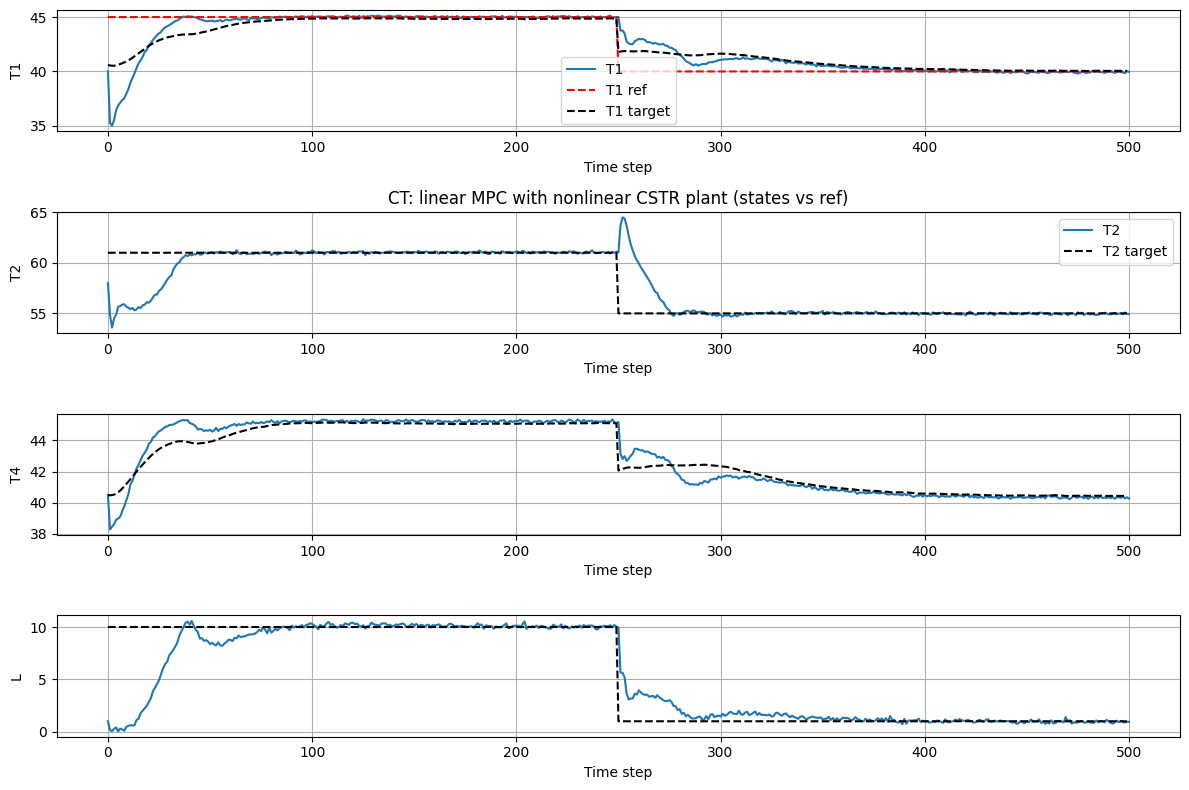

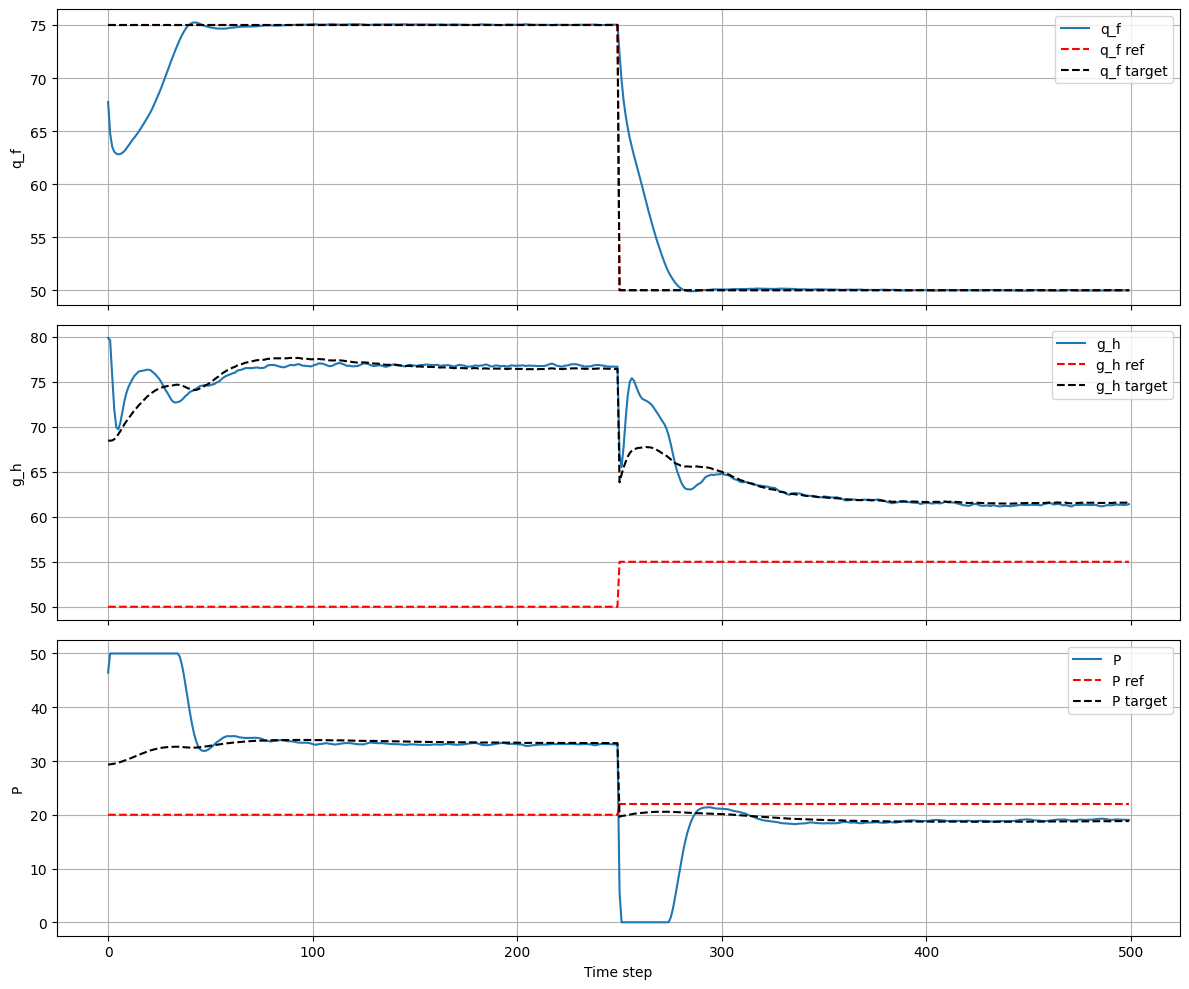

In [65]:
Qu = loaded_setup['Qu']
Qy = loaded_setup['Qy']
Qdu = loaded_setup['Qdu']
objective_value = 0.0
state_error_cost = 0.0
control_increment_cost = 0.0
control_setpoint_cost = 0.0
for k in range(sim_time):
    y_ref_k = ys_sim[:, k]
    y_ref_k = loaded_setup['reference'][:, k]
    y_diff = y_sim[:, k] - ys_sim[:, k]
    prev_u = u_sim[:, k - 1] if k > 0 else u_sim[:, k]
    u_diff = u_sim[:, k] - prev_u
    u_error = us_sim[:, k] - u_sim[:, k]
    y_term = float(y_diff.T @ Qy @ y_diff)
    u_term = float(u_diff.T @ Qdu @ u_diff)
    u_sp_term = float(u_error.T @ Qu @ u_error)
    state_error_cost += y_term
    control_increment_cost += u_term
    control_setpoint_cost += u_sp_term
    objective_value += y_term + u_term + u_sp_term

print(f"Closed-loop objective function value: {objective_value}")
print(f"  - State tracking term: {state_error_cost}")
print(f"  - Input increment term: {control_increment_cost}")
print(f"  - Input setpoint term: {control_setpoint_cost}")

Qu = loaded_setup['Qu']
Qy = loaded_setup['Qy']
objective_value = 0.0
state_error_cost = 0.0
control_setpoint_cost = 0.0
for k in range(sim_time):
    y_ref_k = loaded_setup['reference'][:, k]
    y_diff = y_sim[:, k] - y_ref_k
    u_error = us_sim[:, k] - u_sim[:, k]
    y_term = float(y_diff.T @ Qy @ y_diff)
    u_sp_term = float(u_error.T @ Qu @ u_error)
    state_error_cost += y_term
    control_setpoint_cost += u_sp_term
    objective_value += y_term + u_term + u_sp_term

print(f"Closed-loop objective function value: {objective_value}")
print(f"  - State tracking term: {state_error_cost}")
print(f"  - Input setpoint term: {control_setpoint_cost}")




# Plots saved to figures/ in non-scaled domain (8 states, 4 inputs)
ys_sim_ns = scaler.inverse_transform(ys_sim.T).T
zs_sim_ns = scaler.inverse_transform((C@zs_sim + z_sim[nz:]).T).T
y_ests = scaler.inverse_transform((C@z_sim[:nz]).T).T
us_sim_ns = scalerU.inverse_transform(us_sim.T).T

names = ['T1', 'T2', 'T4', 'L']
n_steps = sim_time

fig, axs = plt.subplots(nrows=min(8, ny), ncols=1, figsize=(12, 8))
if min(8, ny) == 1:
    axs = [axs]  # Ensure axs is always iterable
for i in range(min(8, ny)):
    ax = axs[i]
    # Actual output
    ax.plot(y_sim_ns[i, :], label=names[i] if i < len(names) else f'y{i}')
    # Reference trajectory
    if i == 0:
        ax.plot(reference_ns[i, :n_steps+1], 'r--', label=f'{names[i]} ref' if i < len(names) else f'y{i} ref')
    # Target/Estimated reference
    ax.plot(ys_sim_ns[i, :n_steps], 'k--', label=f'{names[i]} target')
    # State estimate (plot on top)
    # ax.plot(y_ests[i, :n_steps], 'g:', label=f'{names[i]} est' if i < len(names) else f'y{i} est')
    ax.set_xlabel('Time step')
    ax.set_ylabel(names[i] if i < len(names) else f'y{i}')
    ax.grid(True)
    if i in (0,1):
        ax.legend()
    if i == 1:
        ax.set_title('CT: linear MPC with nonlinear CSTR plant (states vs ref)')
plt.tight_layout()
# fig.savefig((figures_dir / 'CT_states.png').as_posix(), dpi=200)


fig_inputs, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
input_names = [ 'q_f','g_h', 'P']
for i in range(len(input_names)):
    axs[i].plot(u_sim_ns[i, :], label=input_names[i])
    axs[i].plot(loaded_setup['reference_u_ns'][i, :n_steps], 'r--', label=f'{input_names[i]} ref')
    axs[i].plot(us_sim_ns[i, :], 'k--', label=f"{input_names[i]} target")
    
    axs[i].set_ylabel(input_names[i])
    axs[i].grid(True)
    axs[i].legend()
axs[-1].set_xlabel('Time step')
fig_inputs.tight_layout()
#644

In [66]:
sum(u_sim_ns[1,:])

np.float64(34851.98726368895)

In [67]:
sum(sum(z_sim[nz:,:]))

np.float64(-126.39912328396714)

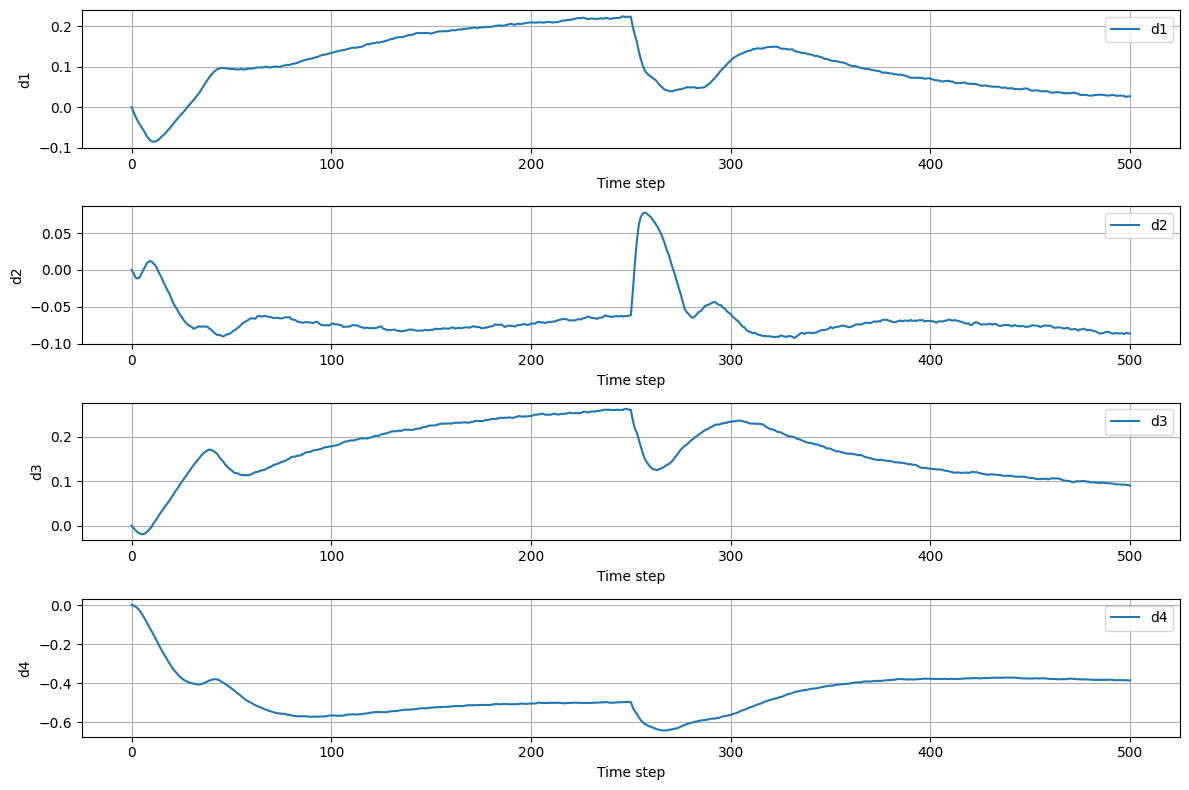

In [68]:
names = [f'd{i+1}' for i in range(z_sim.shape[0] - nz)]
n_plots = len(names)
fig, axs = plt.subplots(nrows=n_plots, ncols=1, figsize=(12, 8))
if n_plots == 1:
    axs = [axs]
for i in range(n_plots):
    ax = axs[i]
    ax.plot(z_sim[nz + i, :], label=names[i])
    ax.set_xlabel('Time step')
    ax.set_ylabel(names[i])
    ax.grid(True)
    ax.legend()
plt.tight_layout()

In [69]:
C@z_sim[:nz] + z_sim[nz:]

array([[ 0.0382261 , -0.30199014, -0.44891994, ...,  0.02538242,
         0.02915084,  0.0289187 ],
       [ 0.16006749, -0.03880728, -0.17836937, ..., -0.24133142,
        -0.24099441, -0.24215944],
       [ 0.12664086, -0.00850102, -0.02671327, ...,  0.0975761 ,
         0.09947498,  0.09816194],
       [-0.38801401, -0.32322383, -0.26586468, ..., -0.39006782,
        -0.39025009, -0.39026288]])

In [70]:
import numpy as np

def modal_time_constants(A, Ts, discrete=True):
    """
    Time scales from eigenvalues of square matrix A.

    If discrete=True (default): assumes x[k+1] = A x[k] with sampling Ts [s].
      tau_env[s] = -Ts / ln(|λ|) for each eigenvalue λ with 0 < |λ| < 1
      (envelope 1/e time; nan if |λ|>=1 or λ==0).

    If discrete=False: assumes ẋ = A x with eigenvalues s,
      tau[s] = -1/Re(s) for Re(s) < 0 (nan otherwise).
    """
    A = np.asarray(A, dtype=float)
    lam = np.linalg.eigvals(A)

    if discrete:
        m = np.clip(np.abs(lam), 1e-300, None)
        tau = np.full_like(lam, np.nan, dtype=float)
        ok = (m > 0.0) & (m < 1.0)
        tau[ok] = -Ts / np.log(m[ok])
        # equivalent continuous-time eigenvalues (principal log), optional insight:
        s_equiv = np.log(lam) / Ts
        return lam, tau, s_equiv

    s = lam
    tau = np.full_like(s, np.nan, dtype=float)
    ok = np.real(s) < 0
    tau[ok] = -1.0 / np.real(s[ok])
    return s, tau

In [71]:
modal_time_constants(A, Ts)

(array([0.69941584+0.14605702j, 0.69941584-0.14605702j,
        0.80998624+0.j        , 0.92216935+0.j        ,
        0.99082848+0.j        , 0.96442923+0.02281257j,
        0.96442923-0.02281257j, 0.9536603 +0.j        ]),
 array([  2.97470786,   2.97470786,   4.74522836,  12.34165747,
        108.53235568,  27.82480787,  27.82480787,  21.07581652]),
 array([-0.33616746+0.20586862j, -0.33616746-0.20586862j,
        -0.21073801+0.j        , -0.08102639+0.j        ,
        -0.00921384+0.j        , -0.03593915+0.02364955j,
        -0.03593915-0.02364955j, -0.04744775+0.j        ]))

In [72]:
scaler.inverse_transform((C@z_sim[:nz] + z_sim[nz:]).T).T

array([[40.        , 38.26039861, 37.50911385, ..., 39.93432736,
        39.95359614, 39.95240919],
       [58.        , 56.50817563, 55.46127492, ..., 54.98897606,
        54.99150414, 54.98276485],
       [40.5       , 39.78218922, 39.68545422, ..., 40.34562152,
        40.35570748, 40.34873322],
       [ 1.        ,  1.77409904,  2.45941386, ...,  0.97546154,
         0.97328377,  0.97313096]])

In [73]:
# # Fast test: Observer tracking constant bias
# print("="*60)
# print("FAST TEST: Observer Open-Loop with Constant Bias")
# print("="*60)

# # ==============================================================================
# # Calculate TRUE bias: steady-state mismatch between baseline and Koopman
# # ==============================================================================
# print("\nCalculating true bias from steady-state mismatch...")

# # Zero input
# u_zero = np.zeros(nu)

# # Baseline plant: find steady-state output with zero input
# print("  Finding baseline plant steady state (u=0)...")
# baseline_inference.init()  # Reset baseline
# n_ss_steps = 5000  # Steps to reach steady state
# for _ in range(n_ss_steps):
#     y_baseline_ss = baseline_inference.y_plus(u_zero)

# print(f"  Baseline steady state (u=0): {y_baseline_ss}")

# # Koopman model: steady-state with zero input
# print("  Finding Koopman model steady state (u=0)...")
# z_koopman_ss = np.zeros(nz)
# for _ in range(n_ss_steps):
#     z_koopman_ss = A @ z_koopman_ss + B @ u_zero
# y_koopman_ss = C @ z_koopman_ss

# print(f"  Koopman steady state (u=0):  {y_koopman_ss}")

# # TRUE BIAS = baseline output - Koopman output (at zero input steady state)
# true_bias = y_baseline_ss - y_koopman_ss

# print(f"\n  TRUE BIAS (model mismatch): {true_bias}")
# print("="*60)

# # Setup scenario
# N_test = 200  # Test horizon

# # Initialize states for the augmented system (Koopman states + disturbance estimate)
# z_test = np.zeros((nz + nd, N_test+1))
# y_test = np.zeros((ny, N_test+1))

# # Initial condition - start from the final state of the main simulation
# z_test[:nz, 0] = z_sim[:nz, -1]  # Use final Koopman state from main simulation
# z_test[nz:, 0] = np.zeros(nd)    # Start with zero disturbance estimate

# # Initial output with bias
# y_test[:, 0] = C @ z_test[:nz, 0] + true_bias

# # Fixed control at steady state
# u_fixed = us_sim[:, -1].reshape(-1, 1)  # Use final control from main simulation

# # Create a simple Kalman filter for this test
# # Using the same Q and R from the main simulation
# P_test = P0.copy()
# TVKF_test = helper.TVKF(A_, B_, C_, z_test[:, [0]].T, P_test, Q, R)

# print(f"\nInitial conditions:")
# print(f"  Koopman state from main sim: {z_test[:nz, 0][:3]}...")  # Show first 3 elements
# print(f"  True bias: {true_bias}")
# print(f"  Fixed control input: {u_fixed.flatten()}")
# print(f"\nRunning {N_test} steps...")

# # Simulate the system
# for k in range(N_test):
#     # True system evolution: use the Koopman model as the "true" system
#     # In practice, you could also use baseline_inference.y_plus(u_fixed) for the physical plant
#     z_true = A @ z_test[:nz, k] + B @ u_fixed.flatten()
#     y_test[:, k+1] = C @ z_true + true_bias  # Add constant bias to output
    
#     # Small measurement noise
#     noise_std = 0.001
#     noise = np.random.normal(0, noise_std, size=ny)
#     y_test[:, k+1] += noise
    
#     # Observer update using the Kalman filter
#     # Note: C_ needs to be constant here since we're using fixed linearization
#     C_test = np.hstack([C, Cd])
    
#     z_test[:, k+1] = TVKF_test.step(
#         u_fixed.flatten(),
#         y_test[:, k+1],
#         C @ z_test[:nz, k],  # Linearization point output
#         z_test[:nz, k],      # Linearization point state
#         C,                    # Jacobian (constant for linear Koopman)
#         C_test
#     ).flatten()

# # Extract estimated disturbance
# d_est_test = z_test[nz:, :]

# # Calculate convergence metrics
# final_error = np.abs(true_bias - d_est_test[:, -1])
# mean_error_last_50 = np.mean(np.abs(true_bias[:, np.newaxis] - d_est_test[:, -50:]), axis=1)

# print(f"\n" + "="*60)
# print("RESULTS:")
# print("="*60)
# print("\nFinal bias estimation (last time step):")
# for i in range(ny):
#     print(f"  Output {i+1}: True={true_bias[i]:+.4f}, Est={d_est_test[i, -1]:+.4f}, Error={final_error[i]:.4f}")

# print(f"\nMean error over last 50 steps:")
# for i in range(ny):
#     print(f"  Output {i+1}: {mean_error_last_50[i]:.4f}")

# # Plot results
# fig, axes = plt.subplots(ny, 1, figsize=(12, 8))
# if ny == 1:
#     axes = [axes]

# for i in range(ny):
#     axes[i].plot(d_est_test[i, :], label=f'Estimated d{i+1}', linewidth=2, alpha=0.8)
#     axes[i].axhline(y=true_bias[i], color='r', linestyle='--', linewidth=2, 
#                     label=f'True bias = {true_bias[i]:+.3f}', alpha=0.8)
#     axes[i].set_ylabel(f'd{i+1}', fontsize=11)
#     axes[i].legend(loc='best')
#     axes[i].grid(True, alpha=0.3)
    
#     # Add shaded region showing final convergence zone
#     axes[i].axhspan(true_bias[i] - 0.01, true_bias[i] + 0.01, 
#                     alpha=0.1, color='green', label='±0.01 tolerance')

# axes[-1].set_xlabel('Time step', fontsize=11)
# fig.suptitle('Observer Tracking of Constant Output Bias\n(Open-Loop Test with Kalman Filter)', 
#              fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.show()

# print("\n" + "="*60)
# print("Test completed successfully!")

FAST TEST 2: Observer with Constant Input to Baseline Plant

Calculating true disturbance from steady-state mismatch...
  Finding baseline plant steady state (u=0)...
Model initialized successfully!
A matrix shape: (24, 24)
B matrix shape: (24, 3)
Scalers loaded for 3 outputs and 3 inputs
  Baseline steady state (u=0): [-0.03620239 -0.04225322  0.02860489 -0.40146923]
  Finding Koopman model steady state (u=0)...
  Koopman steady state (u=0):  [0. 0. 0. 0.]

  TRUE DISTURBANCE (model mismatch): [-0.03620239 -0.04225322  0.02860489 -0.40146923]
Model initialized successfully!
A matrix shape: (24, 24)
B matrix shape: (24, 3)
Scalers loaded for 3 outputs and 3 inputs

Test setup:
  Initial Koopman state: [-0.05264753  0.01284057  0.01330908]...
  Initial output: [ 0.03810897 -0.11198983  0.13590552 -0.38803712]
  Constant control input: [0. 0. 0.]

Running 2000 steps with baseline plant...
[ 0.02888338 -0.08862411  0.079432   -0.3898352 ]
[ 0.02580594 -0.08723225  0.06752654 -0.3904264 ]


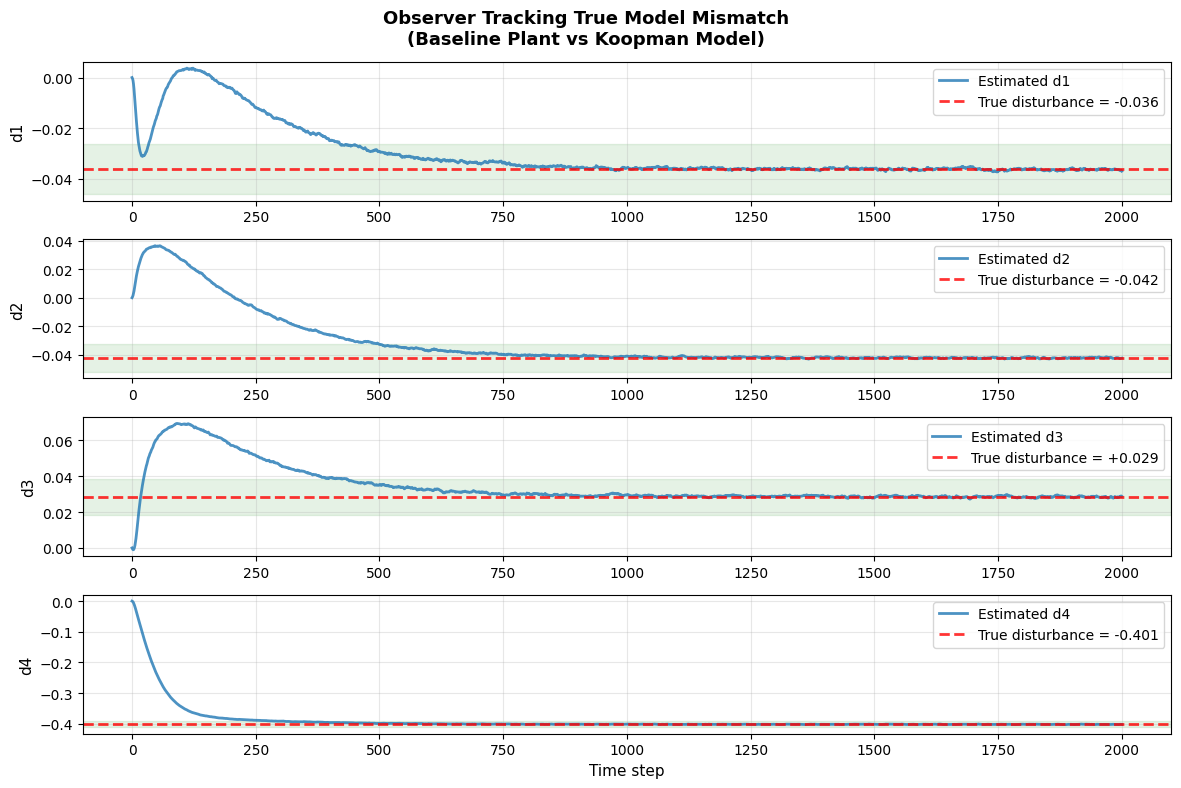


Output comparison (Baseline Plant vs Koopman Prediction):
Baseline plant output:      [-0.04067516 -0.04229439  0.02659931 -0.40339355]
Koopman + est. disturbance: [-0.03735916 -0.04268732  0.02850806 -0.40183571]
Prediction error:           [0.003316   0.00039294 0.00190875 0.00155784]

Estimated disturbance converged to: [-0.03699711 -0.04247635  0.02876869 -0.40175837]
True steady-state mismatch:         [-0.03620239 -0.04225322  0.02860489 -0.40146923]

Test completed successfully!


In [74]:
# Fast test 2: Observer with constant input to baseline plant
print("="*60)
print("FAST TEST 2: Observer with Constant Input to Baseline Plant")
print("="*60)

# ==============================================================================
# Calculate TRUE disturbance: steady-state mismatch between baseline and Koopman
# ==============================================================================
print("\nCalculating true disturbance from steady-state mismatch...")

# Zero input
u_zero = np.zeros(nu)
u_zero_ns = scalerU.inverse_transform(u_zero.reshape(1, -1))[0]
u_zero_bl = scalerU_baseline.transform(u_zero_ns.reshape(1, -1))[0]

# Baseline plant: find steady-state output with zero input
# Run baseline for many steps to reach steady state
print("  Finding baseline plant steady state (u=0)...")
baseline_inference.init()  # Reset baseline
n_ss_steps = 5000  # Steps to reach steady state
for _ in range(n_ss_steps):
    y_bl_scaled = baseline_inference.y_plus(u_zero_bl)
y_bl_ns = scaler_baseline.inverse_transform(y_bl_scaled.reshape(1, -1))[0]
L_ss = 10.0 ** ((y_bl_ns[0] - 40.0) / 5.0)
y_full_ns = np.array([y_bl_ns[0], y_bl_ns[1], y_bl_ns[2], L_ss])
y_baseline_ss = scaler.transform(y_full_ns.reshape(1, -1))[0]

print(f"  Baseline steady state (u=0): {y_baseline_ss}")

# Koopman model: steady-state with zero input
# For a stable linear system, steady state is when z[k+1] = z[k]
# So: z_ss = A @ z_ss + B @ u  =>  (I - A) @ z_ss = B @ u
# With u=0: (I - A) @ z_ss = 0  =>  z_ss = 0 (if A is stable and has no integrators)
# But we can also just simulate it
print("  Finding Koopman model steady state (u=0)...")
z_koopman_ss = np.zeros(nz)
for _ in range(n_ss_steps):
    z_koopman_ss = A @ z_koopman_ss + B @ u_zero
y_koopman_ss = C @ z_koopman_ss

print(f"  Koopman steady state (u=0):  {y_koopman_ss}")

# TRUE DISTURBANCE = baseline output - Koopman output (at zero input steady state)
true_disturbance = y_baseline_ss - y_koopman_ss

print(f"\n  TRUE DISTURBANCE (model mismatch): {true_disturbance}")
print("="*60)

# ==============================================================================
# Run test with constant (non-zero) input
# ==============================================================================
N_test2 = 2000  # Test horizon

# Initialize observer states
z_test2 = np.zeros((nz + nd, N_test2+1))
y_test2 = np.zeros((ny, N_test2+1))

# Start from a known state
# Re-initialize baseline to match a specific state
baseline_inference.init()
# Set initial state by applying the final control from main simulation a few times
us_last_ns = scalerU.inverse_transform(us_sim[:, -1].reshape(1, -1))[0]
us_last_bl = scalerU_baseline.transform(us_last_ns.reshape(1, -1))[0]
for _ in range(10):
    y_bl_sc = baseline_inference.y_plus(us_last_bl)
y_bl_ns_init = scaler_baseline.inverse_transform(y_bl_sc.reshape(1, -1))[0]
L_init = 10.0 ** ((y_bl_ns_init[0] - 40.0) / 5.0)
y_init = scaler.transform(np.array([[y_bl_ns_init[0], y_bl_ns_init[1], y_bl_ns_init[2], L_init]]))[0]

# Initial Koopman state corresponding to this output
z_test2[:nz, 0] = (np.linalg.pinv(C)@y_init).flatten()
z_test2[nz:, 0] = np.zeros(nd)

y_test2[:, 0] = y_init

# Constant control input (use steady-state control from main simulation)
u_const = u_zero  # MPC-scaled
u_const_bl = u_zero_bl  # baseline-scaled

# Create Kalman filter for this test
P_test2 = P0.copy()
TVKF_test2 = helper.KF(A_, B_, C_, z_test2[:, [0]].T, P_test2, Q, R)

print(f"\nTest setup:")
print(f"  Initial Koopman state: {z_test2[:nz, 0][:3]}...")
print(f"  Initial output: {y_test2[:, 0]}")
print(f"  Constant control input: {u_const}")
print(f"\nRunning {N_test2} steps with baseline plant...")

# Simulate with baseline plant
for k in range(N_test2):
    # Step the TRUE physical plant (baseline_inference)
    y_bl_sc_k = baseline_inference.y_plus(u_const_bl)
    y_bl_ns_k = scaler_baseline.inverse_transform(y_bl_sc_k.reshape(1, -1))[0]
    L_k = 10.0 ** ((y_bl_ns_k[0] - 40.0) / 5.0)
    y_plant = scaler.transform(np.array([[y_bl_ns_k[0], y_bl_ns_k[1], y_bl_ns_k[2], L_k]]))[0]
    
    y_test2[:, k+1] = y_plant
    print(y_plant)
    # Add small measurement noise
    noise_std = 0.002
    noise = np.random.normal(0, noise_std, size=ny)
    y_test2[:, k+1] += noise
    
    # Observer prediction and correction using Kalman filter
    C_test2 = np.hstack([C, Cd])
    
    z_test2[:, k+1] = TVKF_test2.step(
        u_const,
        y_test2[:, k+1]
    ).flatten()

# Extract estimated disturbance
d_est_test2 = z_test2[nz:, :]

# Calculate convergence metrics
# NOTE: The true disturbance might differ from steady-state mismatch during transients
# but should converge to it at steady state
final_error2 = np.abs(true_disturbance - d_est_test2[:, -1])
mean_error_last_50_2 = np.mean(np.abs(true_disturbance[:, np.newaxis] - d_est_test2[:, -50:]), axis=1)

print(f"\n" + "="*60)
print("RESULTS:")
print("="*60)
print("\nTrue disturbance (steady-state model mismatch):")
print(f"  {true_disturbance}")

print("\nFinal disturbance estimation (last time step):")
for i in range(ny):
    print(f"  Output {i+1}: True={true_disturbance[i]:+.4f}, Est={d_est_test2[i, -1]:+.4f}, Error={final_error2[i]:.4f}")

print(f"\nMean error over last 50 steps:")
for i in range(ny):
    print(f"  Output {i+1}: {mean_error_last_50_2[i]:.4f}")

# Plot results
fig, axes = plt.subplots(ny, 1, figsize=(12, 8))
if ny == 1:
    axes = [axes]

for i in range(ny):
    axes[i].plot(d_est_test2[i, :], label=f'Estimated d{i+1}', linewidth=2, alpha=0.8)
    axes[i].axhline(y=true_disturbance[i], color='r', linestyle='--', linewidth=2, 
                    label=f'True disturbance = {true_disturbance[i]:+.3f}', alpha=0.8)
    axes[i].set_ylabel(f'd{i+1}', fontsize=11)
    axes[i].legend(loc='best')
    axes[i].grid(True, alpha=0.3)
    
    # Add shaded convergence zone
    axes[i].axhspan(true_disturbance[i] - 0.01, true_disturbance[i] + 0.01, 
                    alpha=0.1, color='green')

axes[-1].set_xlabel('Time step', fontsize=11)
fig.suptitle('Observer Tracking True Model Mismatch\n(Baseline Plant vs Koopman Model)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare outputs: baseline plant vs Koopman model prediction
print("\n" + "="*60)
print("Output comparison (Baseline Plant vs Koopman Prediction):")
print("="*60)
y_koopman_pred = C @ z_test2[:nz, -1] + d_est_test2[:, -1]
y_baseline_actual = y_test2[:, -1]
print(f"Baseline plant output:      {y_baseline_actual}")
print(f"Koopman + est. disturbance: {y_koopman_pred}")
print(f"Prediction error:           {np.abs(y_baseline_actual - y_koopman_pred)}")
print(f"\nEstimated disturbance converged to: {d_est_test2[:, -1]}")
print(f"True steady-state mismatch:         {true_disturbance}")

print("\n" + "="*60)
print("Test completed successfully!")